In [16]:
import os
import sys

import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.neighbors import KNeighborsClassifier
from termcolor import colored

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 18})

# Estimating the generalization ability of the trained PyKAN on the valid/test set

In [17]:
# 1s
train_x, train_y = read_dataset('original', normalization='standardize')
_original_x, _ = read_dataset('original')
train_mean, train_std = _original_x.mean(), _original_x.std()

test_x = read_dataset(stage='original', dataset='test')
test_x_std_on_train = (test_x - train_mean) / train_std

train_pred_kan = pd.read_csv('../3-fault_detection/predictions_train.csv')['faulty']
test_pred_kan = pd.read_csv('../3-fault_detection/predictions_test.csv')['faulty']

In [18]:
train_pca = PCA(train_x)
test_pca = PCA(test_x_std_on_train, loadings=train_pca.loadings)

## Train KNN on the train set in the PCA domain and compare the prediction over the test set with the predictions of the PyKAN
The KNN uses the Euclidean distance between the test points and the labelled train points to make a prediction. Therefore, in this analysis we're asking if the test samples predicted as faulty by the PyKAN are near to faulty train samples.

In [19]:
# 6s
k = 300
knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
knn.fit(train_pca.get_components(num=3).values, train_y['faulty'].values)
test_pred_knn = pd.Series(knn.predict_proba(test_pca.get_components(num=3).values)[:, 1])

In [20]:
kan_certainty = test_pred_kan[test_pred_kan < 0.5].mean(), test_pred_kan[test_pred_kan >= 0.5].mean()
knn_certainty = test_pred_knn[test_pred_knn < 0.5].mean(), test_pred_knn[test_pred_knn >= 0.5].mean()
kan_certainty_train = train_pred_kan[train_pred_kan < 0.5].mean(), train_pred_kan[train_pred_kan >= 0.5].mean()
alignment = 1 - np.mean(np.abs(test_pred_kan - test_pred_knn))
print(f'The alignment score between PyKAN and {k}-NN is -->', colored(f'{alignment:.3f}', 'green', attrs=['bold']))

The alignment score between PyKAN and 300-NN is --> 0.624


In the following plot, we can see that the PyKAN lost some confidence when queried on the test set. This comes to no surprise if we keep in mind that the features domain of the test set significantly differs from that of the train set.

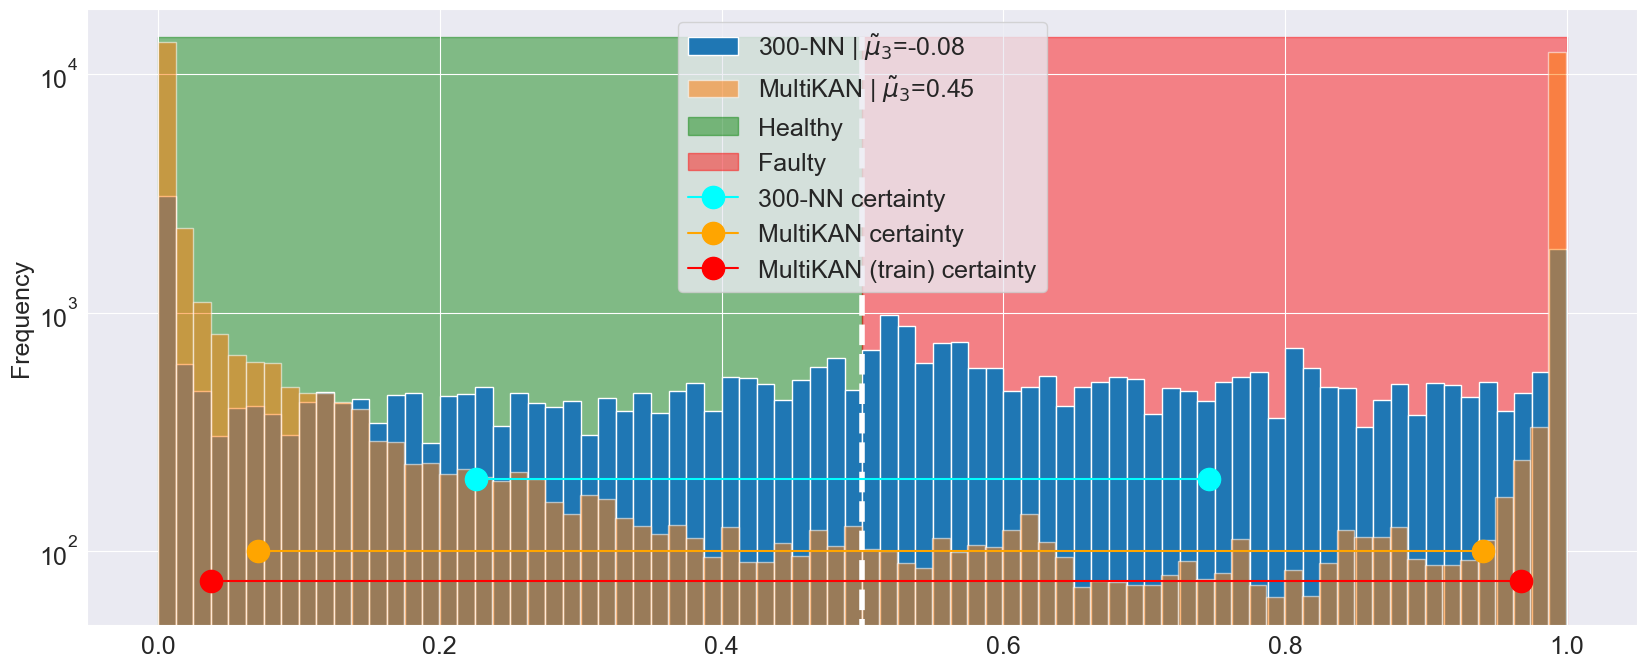

In [21]:
# 1s
ax = test_pred_knn.plot(kind='hist', bins=80, figsize=(20, 8),
                        label=f'{k}-NN | $\\tilde{"{"}\\mu{"}"}_3$={test_pred_knn.skew():.2f}')
test_pred_kan.plot(kind='hist', bins=80, alpha=0.55, ax=ax,
                   label=f'MultiKAN | $\\tilde{"{"}\\mu{"}"}_3$={test_pred_kan.skew():.2f}')
# train_pred_kan.plot(kind='hist', bins=80, alpha=0.55, ax=ax,
#                     label=f'MultiKAN (Train)')
height = ax.get_ylim()[1]
ax.add_line(Line2D([0.5, 0.5], [0, height], linestyle='--', color='w', linewidth=4))
ax.fill_between([0, 0.5], height, alpha=0.45, color='g', zorder=0, label='Healthy')
ax.fill_between([0.5, 1], height, alpha=0.45, color='r', zorder=0, label='Faulty')
ax.plot([knn_certainty[0], knn_certainty[1]], [200] * 2, c='cyan', marker='o', markersize=16, label=f'{k}-NN certainty')
ax.plot([kan_certainty[0], kan_certainty[1]], [100] * 2, 'orange', marker='o', markersize=16,
        label=f'MultiKAN certainty')
ax.plot([kan_certainty_train[0], kan_certainty_train[1]], [75] * 2, 'red', marker='o', markersize=16,
        label=f'MultiKAN (train) certainty')

ax.legend(loc='upper center')
ax.set_yscale('log')
plt.show()

# Plot K-NN prediction

<Axes3D: >

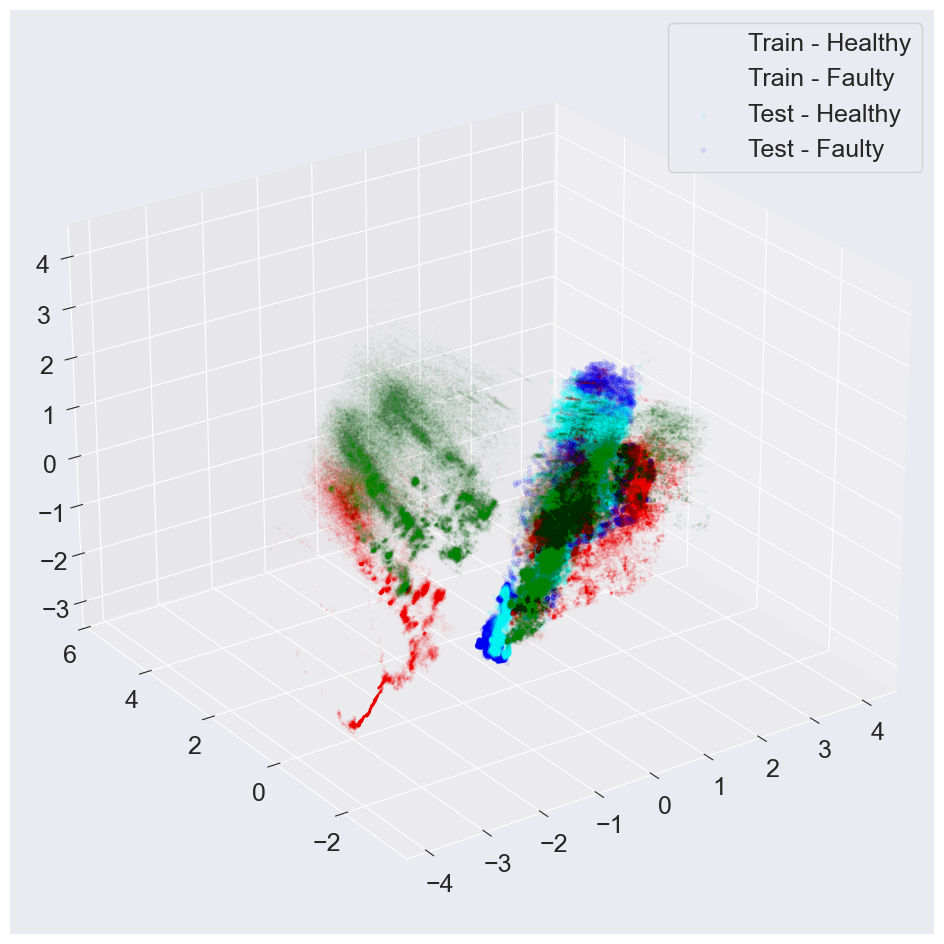

In [22]:
# 15s
ax = train_pca.plot_pca(is_3d=True, hue=train_pred_kan > 0.5, labels={0: 'Train - Healthy', 1: 'Train - Faulty'},
                        scale=1, alpha=0.01)
test_pca.plot_pca(is_3d=True, hue=test_pred_knn > 0.5, labels={0: 'Test - Healthy', 1: 'Test - Faulty'},
                  c={0: 'cyan', 1: 'blue'}, ax=ax, alpha=0.075)